# Lab 6 Final Project

We will optimize the Feedforward Neural Network (FFNN) model for sentiment analysis on the Film Reviews dataset by experimenting with different batch sizes and optimizers. The goal is to find the best configuration that maximizes validation accuracy while minimizing overfitting. We will use the dataset from Lab 5, the [IMDb movie reviews dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews).

## 1.1 Loading the Film Reviews Dataset


In [13]:
import opendatasets as od
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import gensim.downloader
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import preprocess_string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import BertTokenizer, TFBertModel
from sklearn.model_selection import train_test_split
from scipy.special import softmax

# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/javier/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/javier/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/javier/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
movie_reviews_dataset = pd.read_csv('../lab5/datasets/IMDB Dataset.csv')
movie_reviews_dataset.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

In [15]:
print(f"dataset size: {movie_reviews_dataset.shape}")
print(movie_reviews_dataset.columns)
print("Null values per column:")
print(movie_reviews_dataset.isnull().sum())
print("Sentiment value counts:")
print(movie_reviews_dataset['sentiment'].value_counts())
print(f"Number of unknown reviews: {(movie_reviews_dataset['review'] == 'unknown').sum()}")
print(f"Number of empty reviews: {(movie_reviews_dataset['review'].str.strip() == '').sum()}")

dataset size: (50000, 2)
Index(['review', 'sentiment'], dtype='object')
Null values per column:
review       0
sentiment    0
dtype: int64
Sentiment value counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Number of unknown reviews: 0
Number of empty reviews: 0


## 1.2 Preprocessing the Film Reviews Dataset


In [ ]:
def clean_review(text):
    # to string
    text = str(text)
    
    # lower case
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove html tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters, numbers, punctuations (except for apostrophes)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Replace contractions
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "'cause": "because",
        "could've": "could have",
        "won't": "will not",
        "wouldn't": "would not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "it's": "it is",
        "i'm": "I am",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are",
        "that's": "that is",
        "there's": "there is",
        "what's": "what is",
        "who's": "who is",
        "couldn't": "could not",
        "shouldn't": "should not",
        "would've": "would have",
        "let's": "let us",
        "imma": "I am going to",
        "im": "I am",
        "Im": "I am",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'s": " is",
        "'t": " not",
        "'m": " am",
    }
    for contraction, replacement in contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', replacement, text, flags=re.IGNORECASE)

    # Remove stop words (Stop words are common words that do not add much meaning to a sentence, such as "i", "me", "myself", etc.)
    stop_words = set(stopwords.words('english'))
    text_tokens = nltk.word_tokenize(text)
    filtered_words = [word for word in text_tokens if word not in stop_words]
    text = ' '.join(filtered_words)

    return text

In [17]:
movie_reviews_dataset['clean_review'] = movie_reviews_dataset['review'].apply(clean_review)

In [18]:
movie_reviews_dataset.sample(5)

,review,sentiment,clean_review
44777,"Not too many people seem to know about this movie. Which is too bad because I think it's pretty good. Sure it is a bit cheesy at times and may have a predictable storyline. But the presentation of the movie is pretty well done. I think the casting is good with likeable actors/characters. Tom Selleck does a good job at playing a baseball player (go figure... not too much of a stretch I suppose) and Ken Takakura (from Black Rain) plays the chief (the coach of the Japanese baseball team). There isn't too much to complain about. It's just a light, easy-going, happy comedy and I recommend it.",positive,many people seem know movie bad think 's pretty good sure bit cheesy times may predictable storyline presentation movie pretty well done think casting good likeable actors characters tom selleck good job playing baseball player go figure much stretch suppose ken takakura black rain plays chief coach japanese baseball team not much complain 's light easy going happy comedy recommend
15768,"ALICE is the kind of movie they made in the 30's and 40's. Never attempts to be an ""event"". Just wants to entertain. And it does. I was surprised by Kiefer Sutherland. In a role that could be a cliche, he made it real. The plot does make allusions to ALICE IN WONDERLAND. A guy dressed in white does go through a hole and Kiefer does fall down one. Like ALICE the plot does twist and turn, but with a freshness you don't see in small movies. I loved the direction, Sutherland, just a very fast paced and interesting movie.",positive,alice kind movie made 's 's never attempts event wants entertain surprised kiefer sutherland role could cliche made real plot make allusions alice wonderland guy dressed white go hole kiefer fall one like alice plot twist turn freshness not see small movies loved direction sutherland fast paced interesting movie
32147,"Awww, I love this! The Tale of the Cat and the Moon doesn't really need an synopsis, as that's what it is... the cat chasing the moon, to a Spanish poem. It's the artistry that's interesting. In fact, there was this animated short called the Fan and the Flower that was an Academy Award winner last year (2005)... yeah, almost same thing, which leads me to believe it might just be a rip off.<br /><br />But this is a really good short, with stark black & white shapes shifting and transitioning into beautiful motion and poetic seduction... If you believe cats are poetry in motion, see this and you'll believe it more.<br /><br />Also, it has such a touching end.<br /><br />--PolarisDiB",positive,love tale cat moon not really need synopsis 's cat chasing moon spanish poem 's artistry 's interesting fact animated short called fan flower academy award winner last year yeah almost thing leads believe might rip really good short stark black white shapes shifting transitioning beautiful motion poetic seduction believe cats poetry motion see 'll believe also touching end polarisdib
2493,"Valley Girl is the definitive 1980's movie with catch phrases filtered throughout this wonderfully acted movie. The characters are so convincing that you forget it is a movie and not a video of an actual ""day-in-the-life"" of any high school, USA. This flick is to the 1980's what the Brady Bunch TV series is to the 1970's. If you don't like it, well then ""Gag me with a spoon.""",positive,valley girl definitive 's movie catch phrases filtered throughout wonderfully acted movie characters convincing forget movie video actual day life high school usa flick 's brady bunch tv series 's not like well gag spoon
19915,"I love this movie, but can't get what is in this movie tht is not to like. People who don't like this movie must be Richard Roeper and Roger Ebert. But I can't believe that is Mr. Carrey behind all that makeup. And I am sure that most of the actors and actresses in the movie has made film before this. And there is a new face in the movie. Taylor Momsen who plays Cindy Lou Who. As the opens, t

In [19]:
print(movie_reviews_dataset.isnull().sum())

review          0
sentiment       0
clean_review    0
dtype: int64


In [20]:
movie_reviews_dataset['clean_review'] = movie_reviews_dataset['clean_review'].astype(str)

## 1.3 Glove Embeddings for Film Reviews

In [21]:
glove_vectors = gensim.downloader.load('glove-wiki-gigaword-100')

glove-wiki-gigaword-100 is trained with 100-dimensional vectors on Wikipedia 2014 and Gigaword 5 corpus (6B tokens, 400K vocab).

In [ ]:
# this dataset doesn't have neutral reviews so we could skip this step
movie_reviews_dataset = movie_reviews_dataset[movie_reviews_dataset['sentiment'].isin(['positive', 'negative'])]
# binary encoding
movie_reviews_dataset['sentiment'] = movie_reviews_dataset['sentiment'].map({'positive': 1, 'negative': 0})
y = movie_reviews_dataset['sentiment'].values

In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(movie_reviews_dataset['clean_review'].values)
sequences = tokenizer.texts_to_sequences(movie_reviews_dataset['clean_review'].values)
# Same maxlen as glove vector size
X = pad_sequences(sequences, maxlen=100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 100))
for word, i in tokenizer.word_index.items():
    if word in glove_vectors:
        embedding_matrix[i] = glove_vectors[word]

Review texts are sometimes longer than the embedding size (100), so we will truncate them to fit. To avoid losing information, we should study the average and maximum review lengths in the dataset. If we create a maxlen too big it would add a lot of padding to the sequences, which would not be efficient either.

## 1.4 Creating the FFNN Model with Glove Embeddings

In [27]:
model_ffnn = Sequential()
model_ffnn.add(Embedding(input_dim=len(tokenizer.word_index) + 1,
                         output_dim=100,
                         weights=[embedding_matrix],
                         input_length=100,
                         trainable=False))
model_ffnn.add(Flatten())
model_ffnn.add(Dense(1, activation='sigmoid'))
model_ffnn.summary()
model_ffnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn = model_ffnn.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test))

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │    10,619,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,619,200 (40.51 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,619,200 (40.51 MB)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7345 - loss: 0.5383 - val_accuracy: 0.7666 - val_loss: 0.5021
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7921 - loss: 0.4526 - val_accuracy: 0.7529 - val_loss: 0.5393
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8073 - loss: 0.4286 - val_accuracy: 0.7548 - val_loss: 0.5498
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8172 - loss: 0.4124 - val_accuracy: 0.7458 - val_loss: 0.6006
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8203 - loss: 0.4075 - val_accuracy: 0.7448 - val_loss: 0.6027
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8253 - loss: 0.3970 - val_accuracy: 0.7509 - val_loss: 0.6283
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8264 - loss: 0.3921 - val_accuracy: 0.7493 - val_loss: 0.6347
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8299 - loss: 0.3892 - 

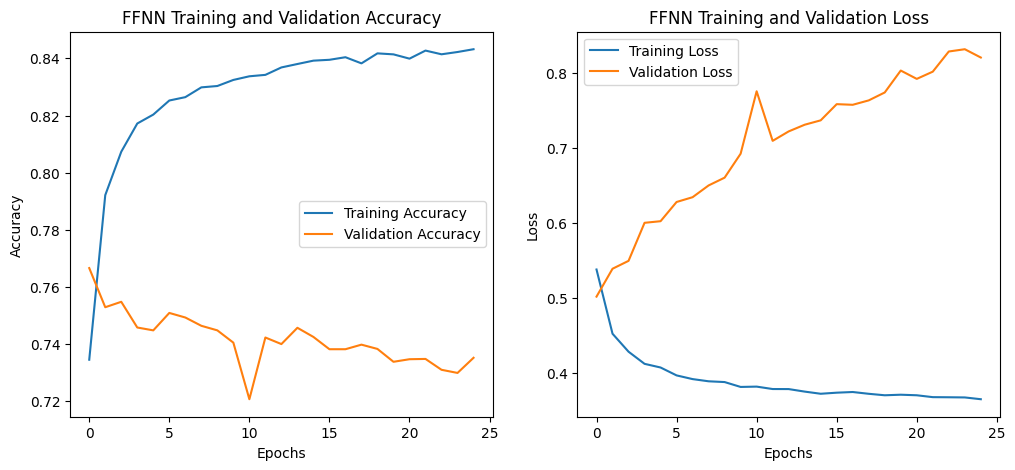

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history_ffnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_ffnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('FFNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ffnn.history['loss'], label='Training Loss')
plt.plot(history_ffnn.history['val_loss'], label='Validation Loss')
plt.title('FFNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training accuracy is 0.84 and Validation accuracy is 0.74 after 25 epochs with batch size 32 and Adam optimizer. So there is some overfitting. Loss also shows that training loss is much lower than validation loss.

### 1.4.1 Experimenting with Different Batch Sizes

In [32]:
model_ffnn_batch = Sequential()
model_ffnn_batch.add(Embedding(input_dim=len(tokenizer.word_index) + 1,
                         output_dim=100,
                         weights=[embedding_matrix],
                         input_length=100,
                         trainable=False))
model_ffnn_batch.add(Flatten())
model_ffnn_batch.add(Dense(1, activation='sigmoid'))
model_ffnn_batch.summary()
model_ffnn_batch.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_batch_64 = model_ffnn_batch.fit(X_train, y_train, epochs=25, batch_size=64, validation_data=(X_test, y_test))
history_ffnn_batch_128 = model_ffnn_batch.fit(X_train, y_train, epochs=25, batch_size=128, validation_data=(X_test, y_test))
history_ffnn_batch_256 = model_ffnn_batch.fit(X_train, y_train, epochs=25, batch_size=256, validation_data=(X_test, y_test))

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │    10,619,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,619,200 (40.51 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,619,200 (40.51 MB)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7317 - loss: 0.5385 - val_accuracy: 0.7523 - val_loss: 0.5140
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7980 - loss: 0.4422 - val_accuracy: 0.7651 - val_loss: 0.5027
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8151 - loss: 0.4144 - val_accuracy: 0.7625 - val_loss: 0.5189
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8210 - loss: 0.4002 - val_accuracy: 0.7607 - val_loss: 0.5354
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8251 - loss: 0.3886 - val_accuracy: 0.7501 - val_loss: 0.5802
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8329 - loss: 0.3795 - val_accuracy: 0.7578 - val_loss: 0.5655
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8341 - loss: 0.3739 - val_accuracy: 0.7482 - val_loss: 0.5840
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8353 - loss: 0.3711 - val_accuracy: 0.

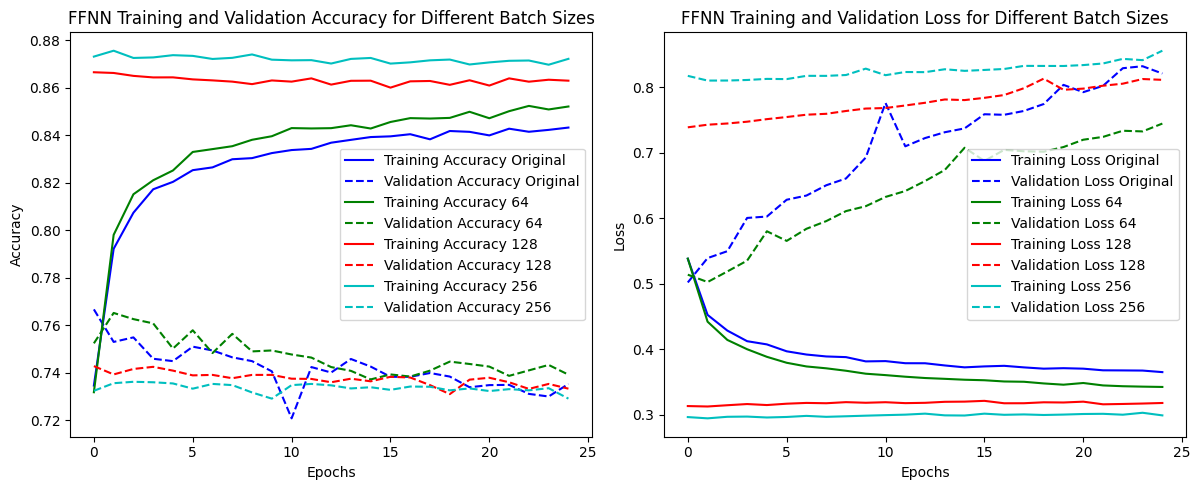

In [36]:
plt.figure(figsize=(18,5))
colors = ['b', 'g', 'r', 'c']
plt.subplot(1, 3, 1)
labels = ['Training Accuracy Original', 'Validation Accuracy Original', 'Training Accuracy 64', 'Validation Accuracy 64', 'Training Accuracy 128', 'Validation Accuracy 128', 'Training Accuracy 256', 'Validation Accuracy 256']
for i, history in enumerate([history_ffnn, history_ffnn_batch_64, history_ffnn_batch_128, history_ffnn_batch_256]):
    plt.plot(history.history['accuracy'], label=labels[i*2], color=colors[i])
    plt.plot(history.history['val_accuracy'], '--', label=labels[i*2 + 1], color=colors[i])
plt.title('FFNN Training and Validation Accuracy for Different Batch Sizes')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
labels_loss = ['Training Loss Original', 'Validation Loss Original', 'Training Loss 64', 'Validation Loss 64', 'Training Loss 128', 'Validation Loss 128', 'Training Loss 256', 'Validation Loss 256']
for i, history in enumerate([history_ffnn, history_ffnn_batch_64, history_ffnn_batch_128, history_ffnn_batch_256]):
    plt.plot(history.history['loss'], label=labels_loss[i*2], color=colors[i])
    plt.plot(history.history['val_loss'], '--', label=labels_loss[i*2 + 1], color=colors[i])
plt.title('FFNN Training and Validation Loss for Different Batch Sizes')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

We will keep batch size of 64 as the accuracy is a bit better than Original batch size of 32. And the loss decreases smoother than batch sizes of 128 and 256. 

### 1.4.2 Initialization

We initialize the weights of the FFNN model using Glorot uniform initialization.

In [37]:
model_ffnn_initialization = Sequential()
model_ffnn_initialization.add(Embedding(input_dim=len(tokenizer.word_index) + 1,
                         output_dim=100,
                         weights=[embedding_matrix],
                         input_length=100,
                         trainable=False))
model_ffnn_initialization.add(Flatten())
model_ffnn_initialization.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform'))
model_ffnn_initialization.summary()
model_ffnn_initialization.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_initialization = model_ffnn_initialization.fit(X_train, y_train, epochs=25, batch_size=64, validation_data=(X_test, y_test))

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │    10,619,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,619,200 (40.51 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,619,200 (40.51 MB)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7286 - loss: 0.5384 - val_accuracy: 0.7673 - val_loss: 0.4937
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7976 - loss: 0.4436 - val_accuracy: 0.7670 - val_loss: 0.5050
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8124 - loss: 0.4167 - val_accuracy: 0.7633 - val_loss: 0.5174
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8202 - loss: 0.4045 - val_accuracy: 0.7577 - val_loss: 0.5372
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8259 - loss: 0.3903 - val_accuracy: 0.7581 - val_loss: 0.5530
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8307 - loss: 0.3826 - val_accuracy: 0.7530 - val_loss: 0.5767
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8340 - loss: 0.3756 - val_accuracy: 0.7507 - val_loss: 0.5817
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8363 - loss: 0.3688 - val_accuracy: 0.

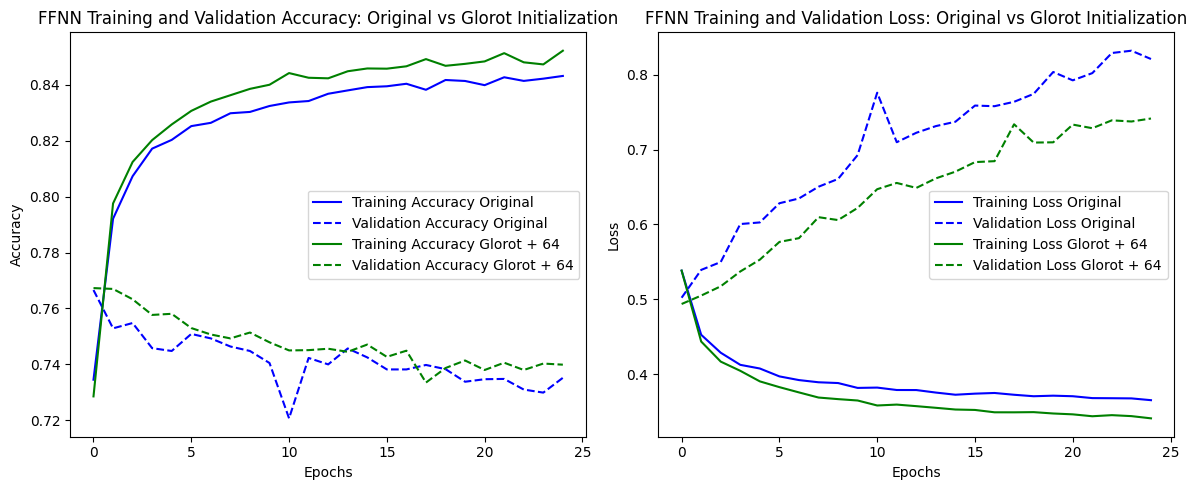

In [38]:
plt.figure(figsize=(12,5))
colors = ['b', 'g']
labels = ['Training Accuracy Original', 'Validation Accuracy Original', 'Training Accuracy Glorot + 64', 'Validation Accuracy Glorot + 64']
plt.subplot(1, 2, 1)
for i, history in enumerate([history_ffnn, history_ffnn_initialization]):
    plt.plot(history.history['accuracy'], label=labels[i*2], color=colors[i])
    plt.plot(history.history['val_accuracy'], '--', label=labels[i*2 + 1], color=colors[i])
plt.title('FFNN Training and Validation Accuracy: Original vs Glorot Initialization')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['Training Loss Original', 'Validation Loss Original', 'Training Loss Glorot + 64', 'Validation Loss Glorot + 64']
for i, history in enumerate([history_ffnn, history_ffnn_initialization]):
    plt.plot(history.history['loss'], label=labels_loss[i*2], color=colors[i])
    plt.plot(history.history['val_loss'], '--', label=labels_loss[i*2 + 1], color=colors[i])
plt.title('FFNN Training and Validation Loss: Original vs Glorot Initialization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The accuracy with Glorot uniform initialization is a bit better with less overfitting compared to the original model without specific initialization. Loss is also decreasing more smoothly with less gap between training and validation loss. But we still see overfitting.

### 1.4.3 Regularization

#### 1.4.3.1 Adding hidden layers, Batch Normalization, Dropout and L1, L2 Regularization, Early Stopping and Adam Optimizer with learning rate 0.001 and lr decay

Batch Normalization here is truly recommended as we are using a pre-trained embedding layer. 
Similarly, Dropout is not recommended either as the model is too simple. However, we will still try it along with L1, L2 regularization to see if it helps reduce overfitting. And we will configure early stopping and lr schedule as callbacks.

In [46]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

loss_ffnn, accuracy_ffnn = model_ffnn.evaluate(X_test, y_test)

def lr_schedule(epoch, lr):
    if epoch > 10:
        lr = lr * np.exp(-0.1)
    return lr

model_ffnn_best = Sequential()
model_ffnn_best.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True))
model_ffnn_best.add(Flatten())
model_ffnn_best.add(Dense(128, activation='relu', kernel_initializer='glorot_uniform'))
model_ffnn_best.add(BatchNormalization())
model_ffnn_best.add(Dense(64, activation='relu', kernel_initializer='glorot_uniform'))
model_ffnn_best.add(BatchNormalization())
model_ffnn_best.add(Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min', verbose=1)
lr_scheduler = LearningRateScheduler(lr_schedule)

model_ffnn_best.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_best = model_ffnn_best.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=64, callbacks=[early_stopping_callback, lr_scheduler])

lost_ffnn_best, accuracy_ffnn_best = model_ffnn_best.evaluate(X_test, y_test)

print(f"FFNN Test Accuracy (initial model): {accuracy_ffnn:.4f}")
print(f"FFNN Test Accuracy (best model): {accuracy_ffnn_best:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - accuracy: 0.7352 - loss: 0.8210
Epoch 1/50


/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.7808 - loss: 0.5280 - val_accuracy: 0.8436 - val_loss: 0.3888 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9128 - loss: 0.2730 - val_accuracy: 0.8540 - val_loss: 0.3830 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9690 - loss: 0.1433 - val_accuracy: 0.8228 - val_loss: 0.5063 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9895 - loss: 0.0799 - val_accuracy: 0.8492 - val_loss: 0.4513 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9937 - loss: 0.0565 - val_accuracy: 0.8469 - val_loss: 0.5485 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9962 - loss: 0.0429 - val_accuracy: 0.8374 - val_loss: 0.6087 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9975 - loss: 0.0345

LR schedule will reduce the learning rate by half every 10 epochs, but in this case it was not really necessary as early stopping stopped the training before 10 epochs.

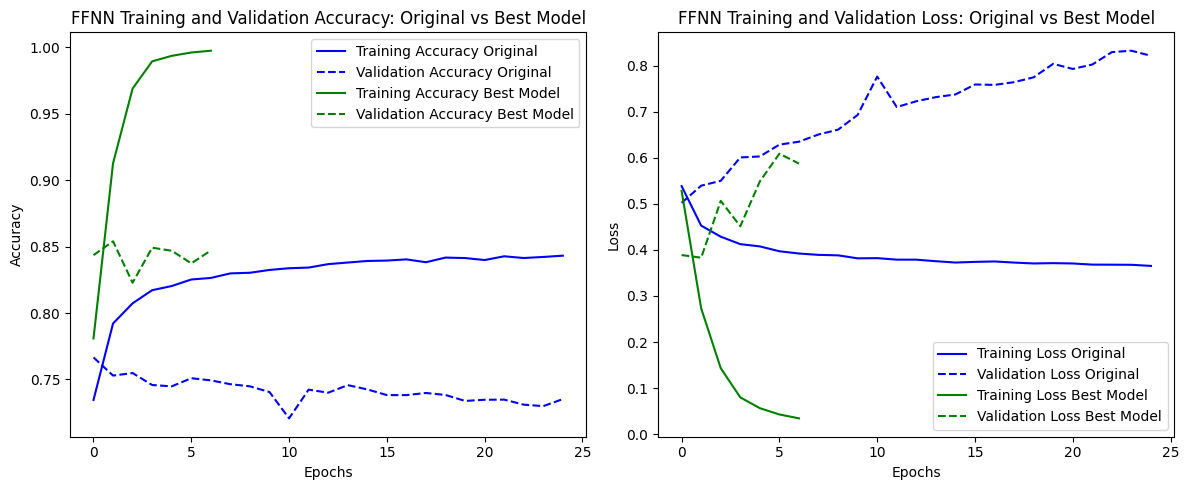

In [47]:
plt.figure(figsize=(12,5))
colors = ['b', 'g']
labels = ['Training Accuracy Original', 'Validation Accuracy Original', 'Training Accuracy Best Model', 'Validation Accuracy Best Model']
plt.subplot(1, 2, 1)
for i, history in enumerate([history_ffnn, history_ffnn_best]):
    plt.plot(history.history['accuracy'], label=labels[i*2], color=colors[i])
    plt.plot(history.history['val_accuracy'], '--', label=labels[i*2 + 1], color=colors[i])
plt.title('FFNN Training and Validation Accuracy: Original vs Best Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['Training Loss Original', 'Validation Loss Original', 'Training Loss Best Model', 'Validation Loss Best Model']
for i, history in enumerate([history_ffnn, history_ffnn_best]):
    plt.plot(history.history['loss'], label=labels_loss[i*2], color=colors[i])
    plt.plot(history.history['val_loss'], '--', label=labels_loss[i*2 + 1], color=colors[i])
plt.title('FFNN Training and Validation Loss: Original vs Best Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


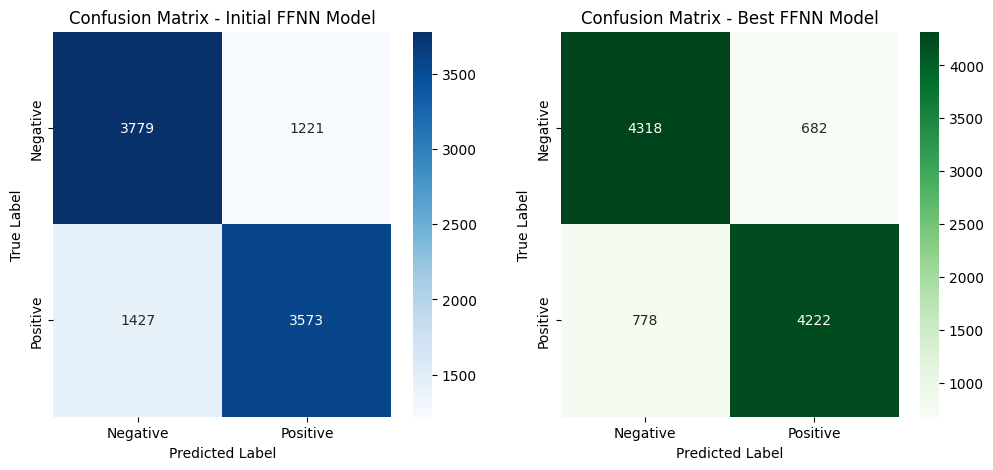

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_ffnn = (model_ffnn.predict(X_test) > 0.5).astype("int32")
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
y_pred_ffnn_best = (model_ffnn_best.predict(X_test) > 0.5).astype("int32")
cm_ffnn_best = confusion_matrix(y_test, y_pred_ffnn_best)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Initial FFNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.subplot(1, 2, 2)
sns.heatmap(cm_ffnn_best, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Best FFNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Best Model has 778 false positives and 682 false negatives. So it improved a lot compared to the original model which had 1427 false positives and 1221 false negatives. The accuracy is 0.8540 vs 0.7352.